In [15]:
import os
import torch
from torchvision import transforms
from torch.utils.data import DataLoader
import torch
from tqdm import tqdm
import numpy as np
import torch
import os
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
transform = transforms.Compose([
        transforms.ToTensor()
        ])


In [4]:
from dataset_compound import PolygonDataset
from cls_xyshift_utils import LATENT_DIM, LinearClassifier, evaluate_model, criterion2

In [5]:
device = "cuda" 

In [109]:
model_no_op = LinearClassifier(num_classes=9).to(device)
mode="no_op"
save_dir = f"checkpoints/mnist_xyshift_cls_{mode}"

In [110]:
best_ckpt = torch.load(os.path.join  (save_dir, "best.pth"))
model_no_op.load_state_dict(best_ckpt['model_state_dict'])

<All keys matched successfully>

In [111]:
def evaluate_no_op_model(model, loader, device):
    model.eval()
    total_loss = 0
    total_samples = 0
    total_correct = 0

    with torch.no_grad():
        for batch in loader:
            img_a, cls = [b.to(device) for b in batch]
          
            _, logits1 = model(img_a)

            loss = criterion2(logits1, cls) 

            # Metrics calculation
            total_loss += loss.item() * img_a.size(0)
            total_samples += img_a.size(0) 
            preds1 = logits1.argmax(dim=1)
            total_correct += (preds1 == cls).sum().item() 

    avg_loss = total_loss / total_samples
    acc = total_correct / total_samples
    print(acc)
    return acc

In [112]:
# degrees reordered so 0° is visually centered
degrees = np.array(range(0,28,2))

acc_list_no_op = {}

for d1 in (degrees):
    for d2 in (degrees):
        ds = PolygonDataset(
            csv_file="mnist_dataset_split.csv",
            split="test",
            transform=transform,
            keep_degrees=(d1, d2),
        )
        loader = DataLoader(ds, batch_size=512, shuffle=False)
        acc_list_no_op[(d1//2, d2//2)] = evaluate_no_op_model(model_no_op, loader, device)


0.8692025358692025
0.808252697141586
0.7726615504393283
0.7708819931042153
0.7891224557891224
0.7795573351128907
0.7935713491269046
0.813257702146591
0.8051384718051384
0.7903459014570126
0.8111444778111445
0.8093649204760316
0.7725503281058836
0.7734401067734401
0.8341675008341675
0.7510844177510844
0.6542097653208764
0.638527416305194
0.6354131909687465
0.5957068179290401
0.5940384829273718
0.6020464909353799
0.5696807919030141
0.5826938049160272
0.6031587142698254
0.6380825269714159
0.5998220442664887
0.6524302079857636
0.781225670114559
0.5971527082638194
0.3770437103770437
0.3283283283283283
0.2702702702702703
0.24680235791346902
0.24302079857635414
0.24791458124791457
0.25403180958736515
0.24646869091313536
0.21421421421421422
0.25981537092648205
0.29140251362473585
0.4621287954621288
0.7892336781225671
0.5117339561784007
0.24780335891447003
0.2092092092092092
0.13591369146924703
0.13213213213213212
0.12757201646090535
0.1662773884996107
0.19697475253030808
0.15637860082304528
0.

In [113]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Determine dimensions
max_d1 = max(k[0] for k in acc_list_no_op.keys())
max_d2 = max(k[1] for k in acc_list_no_op.keys())

# 2. Create empty matrix (initialized to zero or NaN)
grid = np.zeros((max_d1 + 1, max_d2 + 1))

# 3. Fill the matrix
for (d1, d2), acc in acc_list_no_op.items():
    grid[d1, d2] = acc


In [117]:
import numpy as np

# Save to a file named 'accuracy_grid.npy'
np.save('accuracy_grid_no_op_full.npy', grid)

# To reload it later:
# grid = np.load('accuracy_grid.npy')


In [114]:


# Assuming 'grid' is your (N, N) array from the previous step
N = grid.shape[0]
shift = N // 2

# Roll both axes to bring (0,0) to the center
shifted_grid = np.roll(grid, shift=(shift, shift), axis=(0, 1))

# Create labels that reflect the original d1, d2 values
# This ensures the tick marks say "0" in the middle
ticks = np.arange(N)
labels = (ticks - shift) *2


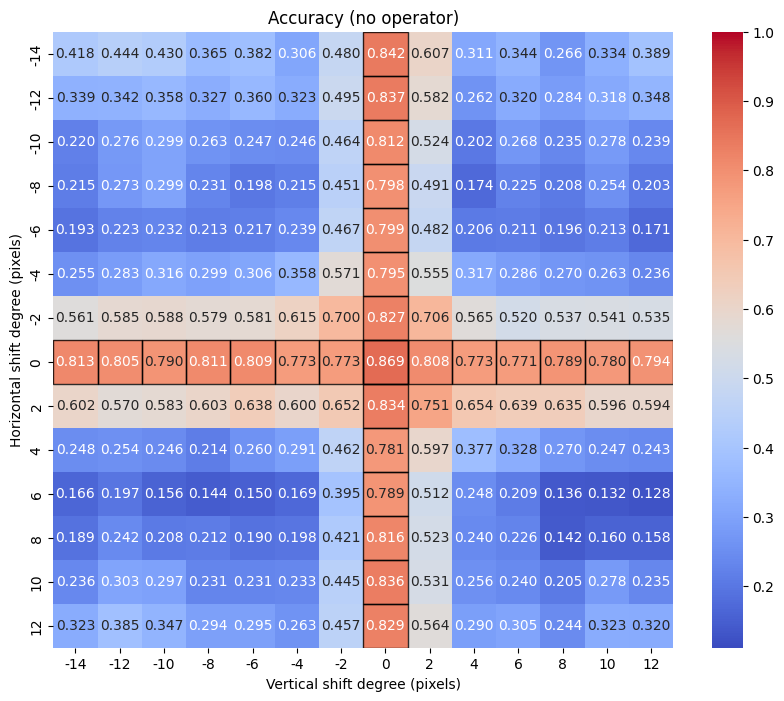

In [116]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.figure(figsize=(10, 8))

# 1. Plot the standard heatmap
ax = sns.heatmap(
    shifted_grid, 
    annot=True, 
    fmt=".3f", 
    cmap="coolwarm",
    vmin=1/9,
    vmax=1,
    xticklabels=labels, 
    yticklabels=labels
)

# 2. Identify the index where the label is 0
zero_pos = np.where(labels == 0)[0][0]

# 3. Add the //// pattern using patches
# We loop through the row and column corresponding to the zero-axis
N = shifted_grid.shape[0]

for i in range(N):
    # Hatch the row (d1 = 0)
    rect_h = patches.Rectangle((i, zero_pos), 1, 1, fill=False,  edgecolor='black', alpha=0.8)
    ax.add_patch(rect_h)
    
    # Hatch the column (d2 = 0)
    rect_v = patches.Rectangle((zero_pos, i), 1, 1, fill=False, edgecolor='black', alpha=0.8)
    ax.add_patch(rect_v)

plt.title("Accuracy (no operator)")
plt.xlabel("Vertical shift degree (pixels)")
plt.ylabel("Horizontal shift degree (pixels)")
plt.show()


In [8]:
def evaluate_fixed_op_model(model, loader, d1, d2, device):
    model.eval()
    total_loss = 0
    total_samples = 0
    total_correct = 0

    with torch.no_grad():
        for batch in loader:
            img_a, cls = [b.to(device) for b in batch]
            idx_a = torch.ones_like(cls) * d1 //2
            idx_t = torch.ones_like(cls) * d2 //2

            _, logits1 = model(img_a, degs1=-idx_a, degs2=-idx_t)

            loss = criterion2(logits1, cls) 

            # Metrics calculation
            total_loss += loss.item() * img_a.size(0)
            total_samples += img_a.size(0) 
            preds1 = logits1.argmax(dim=1)
            total_correct += (preds1 == cls).sum().item() 

    avg_loss = total_loss / total_samples
    acc = total_correct / total_samples
    print(acc)
    return acc

In [54]:
model_fixed_op = LinearClassifier(block_size=14, num_classes=9).to(device)
mode="fixed_op"
save_dir = f"checkpoints/mnist_xyshift_cls_{mode}_22,24,26,0,2,4,6"

In [55]:
best_ckpt = torch.load(os.path.join  (save_dir, "best.pth"))
model_fixed_op.load_state_dict(best_ckpt['model_state_dict'])

<All keys matched successfully>

In [56]:
# degrees reordered so 0° is visually centered
degrees = np.array(range(0,28,2))

acc_list_no_op = {}

for d1 in (degrees):
    for d2 in (degrees):
        ds = PolygonDataset(
            csv_file="mnist_dataset_split.csv",
            split="test",
            transform=transform,
            keep_degrees=(d1, d2),
        )
        loader = DataLoader(ds, batch_size=512, shuffle=False)
        
        acc_list_no_op[(d1//2, d2//2)] = evaluate_fixed_op_model(model_fixed_op,  loader,d1, d2, device)


0.9536202869536203
0.9538427316205094
0.9501723946168391
0.9457235012790568
0.8898898898898899
0.7315092870648426
0.6418640863085308
0.6601045489934378
0.7697697697697697
0.8361695028361695
0.9047936825714603
0.9378267156044934
0.9437214992770548
0.9508397286175064
0.9520631742853966
0.9330441552663775
0.8596374151929708
0.6908019130241353
0.5597820042264486
0.40551662773884994
0.2982982982982983
0.28350572795017237
0.24669113558002448
0.29062395729062396
0.512401290179068
0.810254699143588
0.8872205538872205
0.9295962629295963
0.9518407296185074
0.9156934712490268
0.882104326548771
0.7684351017684351
0.5611166722277834
0.45345345345345345
0.46201757312868424
0.40551662773884994
0.4087420754087421
0.4463352241130019
0.6614392169947726
0.818262707151596
0.9025692359025692
0.927149371593816
0.9475030586141697
0.9133578022466912
0.8401735068401736
0.6854632410187965
0.45045045045045046
0.3784896007118229
0.24546768991213436
0.2752752752752753
0.23923923923923923
0.25202980758536314
0.5379

In [57]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Determine dimensions
max_d1 = max(k[0] for k in acc_list_no_op.keys())
max_d2 = max(k[1] for k in acc_list_no_op.keys())

# 2. Create empty matrix (initialized to zero or NaN)
grid = np.zeros((max_d1 + 1, max_d2 + 1))

# 3. Fill the matrix
for (d1, d2), acc in acc_list_no_op.items():
    grid[d1, d2] = acc


In [58]:
import numpy as np

# Save to a file named 'accuracy_grid.npy'
np.save('accuracy_grid_22,24,26,0,2,4,6.npy', grid)

# To reload it later:
# grid = np.load('accuracy_grid.npy')


In [66]:
import numpy as np

# Load the binary file back into a variable
grid = np.load('accuracy_grid_full.npy')

print(grid.shape)
print(grid)


(14, 14)
[[0.95740185 0.95362029 0.95206317 0.95261929 0.95395395 0.95306418
  0.95551107 0.95473251 0.95528862 0.95895896 0.95595596 0.9511734
  0.95072851 0.95339784]
 [0.95462129 0.9228117  0.83149816 0.73918363 0.60760761 0.47480814
  0.47847848 0.4785897  0.440218   0.47736626 0.58502947 0.73695918
  0.8590813  0.92448004]
 [0.95551107 0.92436881 0.8998999  0.8476254  0.776888   0.70503837
  0.69947726 0.76053832 0.69113558 0.73328884 0.72094317 0.77955734
  0.85796908 0.92992993]
 [0.95907018 0.9372706  0.90534979 0.85974864 0.72872873 0.59937715
  0.50294739 0.55121788 0.63863864 0.65420977 0.72850628 0.78011345
  0.8655322  0.93771549]
 [0.95484373 0.92992993 0.87309532 0.77110444 0.69903237 0.63930597
  0.62840618 0.59826493 0.63018574 0.68390613 0.73195418 0.85040596
  0.90256924 0.94338783]
 [0.9591814  0.94716939 0.88210433 0.80591703 0.66054944 0.59437215
  0.61416973 0.64319875 0.67311756 0.73239907 0.78345012 0.8550773
  0.91669447 0.9407185 ]
 [0.95439884 0.94194194 0.8

In [69]:


# Assuming 'grid' is your (N, N) array from the previous step
N = grid.shape[0]
shift = N // 2

# Roll both axes to bring (0,0) to the center
shifted_grid = np.roll(grid, shift=(shift, shift), axis=(0, 1))

# Create labels that reflect the original d1, d2 values
# This ensures the tick marks say "0" in the middle
ticks = np.arange(N)
labels = (ticks - shift) 


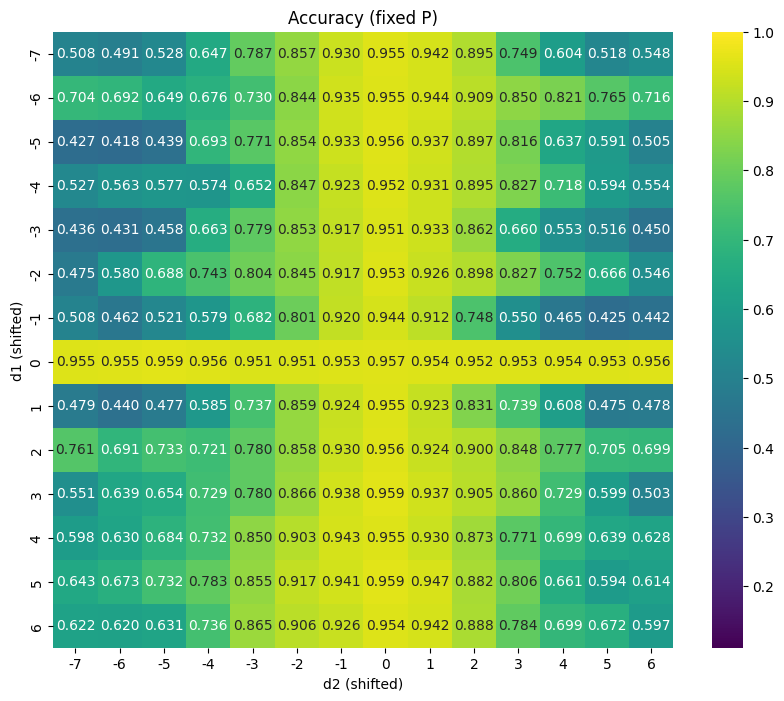

In [70]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    shifted_grid, 
    annot=True, 
    fmt=".3f", 
    cmap="viridis",
    vmin=1/9,
    vmax=1,
    xticklabels=labels, 
    yticklabels=labels
)

# Visual aid: draw lines to highlight the new center axes
#plt.axvline(shift + 0.5, color='white', linewidth=2, linestyle='--')
#plt.axhline(shift + 0.5, color='white', linewidth=2, linestyle='--')

plt.title("Accuracy (fixed P)")
plt.xlabel("d2 (shifted)")
plt.ylabel("d1 (shifted)")
plt.show()


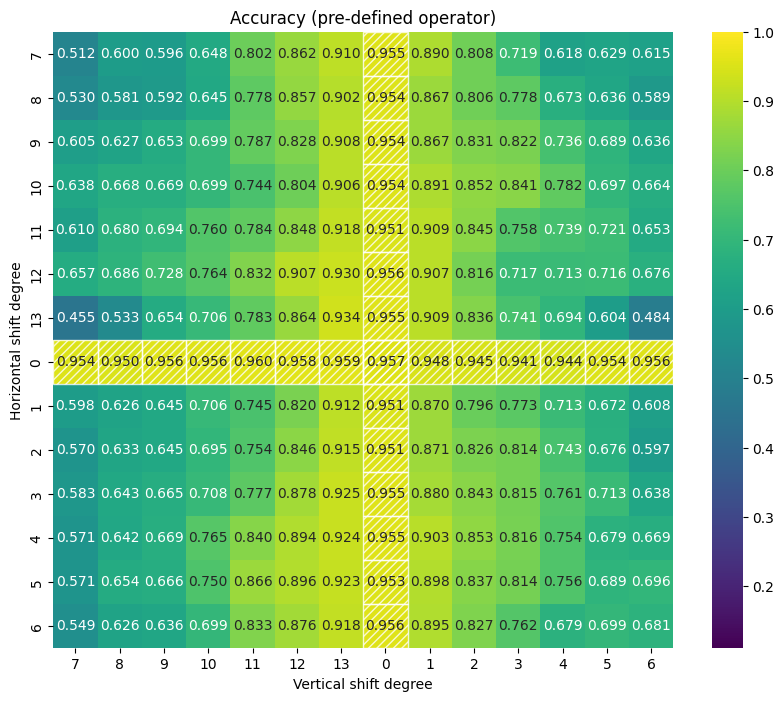

In [76]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.figure(figsize=(10, 8))

# 1. Plot the standard heatmap
ax = sns.heatmap(
    shifted_grid, 
    annot=True, 
    fmt=".3f", 
    cmap="viridis",
    vmin=1/9,
    vmax=1,
    xticklabels=labels, 
    yticklabels=labels
)

# 2. Identify the index where the label is 0
zero_pos = np.where(labels == 0)[0][0]

# 3. Add the //// pattern using patches
# We loop through the row and column corresponding to the zero-axis
N = shifted_grid.shape[0]

for i in range(N):
    # Hatch the row (d1 = 0)
    rect_h = patches.Rectangle((i, zero_pos), 1, 1, fill=False, hatch='////', edgecolor='white', alpha=0.8)
    ax.add_patch(rect_h)
    
    # Hatch the column (d2 = 0)
    rect_v = patches.Rectangle((zero_pos, i), 1, 1, fill=False, hatch='////', edgecolor='white', alpha=0.8)
    ax.add_patch(rect_v)

plt.title("Accuracy (pre-defined operator)")
plt.xlabel("Vertical shift degree")
plt.ylabel("Horizontal shift degree")
plt.show()


In [13]:
trained_degrees = [24, 26, 0, 2, 4]
val_set   = PolygonDataset("mnist_dataset_split.csv", split="val",   
                            transform=transform,
                            transform_type="shift_y",
                            keep_degrees=trained_degrees)
val_loader = DataLoader(ds, batch_size=256, shuffle=False)

In [14]:
import random
import torch
from tqdm import tqdm

# 1. Collect all items into one flat list
all_items = []
for img_anchor, deg_anchor, _, _, _ in tqdm(val_loader):
    for i in range(img_anchor.size(0)):
        all_items.append((img_anchor[i], deg_anchor[i]))

# 2. Sample 200 items once from the entire pool
random.seed(42)
samples = random.sample(all_items, 2000)

# 3. Batch process
imgs = torch.stack([s[0] for s in samples]).to(device)
degs = torch.tensor([s[1] for s in samples]).to(device)

with torch.no_grad():
    # Canonical rotation indexes and forward pass
    emb, _ = model_fixed_op(imgs, skip_transform=False, degs=-(degs // 2))

# Store as a single embedding tensor
ref_embeddings = emb.cpu()


100%|██████████| 36/36 [00:03<00:00, 10.90it/s]


In [ ]:
def evaluate_with_refs(model, loader, ref_images, device):
    model.eval()
    
    # ref_images: (K, D) - Used only for finding the best rotation
    ref_images = ref_images.to(device)
    K = ref_images.size(0) 
    
    ops = torch.arange(14, device=device)
    total = 0
    correct = 0
    correct_deg = 0

    with torch.no_grad():
        for img_anchor, d, cls, _, _ in (loader):
            img_anchor = img_anchor.to(device)
            d = d.to(device)
            cls = cls.to(device)
            B = img_anchor.size(0)

            # 1. Rotate & Forward pass for all 14 rotations
            img14 = img_anchor.unsqueeze(1).repeat(1, 14, 1, 1, 1).view(B * 14, *img_anchor.shape[1:])
            ops14 = ops.repeat(B)
            
            emb14, _ = model(img14, degs=-ops14) # shape: (B*14, D)
            D = emb14.shape[-1]
            emb14_reshaped = emb14.view(B, 14, D)

            # 2. Stage 1: Find best rotation (Agnostic k-NN)
            # Distance from every rotation to the 200 references
            dists = torch.cdist(emb14_reshaped, ref_images.unsqueeze(0)) # (B, 14, 200)
            best_rot_indices = []
            for i in range(B):
                # Find top 3 closest refs across all 14 rotations
                top3_flat_idx = dists[i].view(-1).topk(10, largest=False).indices
                rot_votes = top3_flat_idx // K 
                #print(rot_votes.mode().values.item())
                best_rot_indices.append(rot_votes.mode().values.item())
            
            best_rot = torch.tensor(best_rot_indices, device=device)

            # 3. Stage 2: Gather best embeddings
            # Indexing to get (B, D)
            #print(emb14_reshaped.shape)
            emb_best = emb14_reshaped[torch.arange(B), d]

            # Use the model's classification head
            logits = model.decode(emb_best) 
            pred = logits.argmax(dim=1)
            correct_deg += (best_rot==d//2).sum().item()
            correct += (pred == cls).sum().item()
            total += B
    print(best_rot)
    print("predict", correct_deg/total)
    return correct / total


In [87]:
# degrees reordered so 0° is visually centered
degrees = np.array(range(0,28,2))

acc_list_no_op = []

for d in (degrees):
    ds = PolygonDataset(
        csv_file="mnist_dataset_split.csv",
        split="test",
        transform=transform,
        transform_type="shift_y",
        keep_degrees=[d],
    )
    loader = DataLoader(ds, batch_size=256, shuffle=False)
    acc = evaluate_with_refs(model_fixed_op, loader, ref_embeddings, device)
    print(acc)


tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0], device='cuda:0')
predict 1.0
0.9628517406295184
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0], device='cuda:0')
predict 0.0
0.7992436881325771
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0], device='cuda:0')
predict 0.0
0.2425759092425759
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0], device='cuda:0')
predict 0.0
0.055277499721944165
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0], device='cuda:0')
predict 0.0
0.058836614392169945
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0], device='cuda:0')
predict 0.0
0.14770325881436994
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [45]:
model_learned_op =LinearClassifier(block_size=LATENT_DIM, num_classes=9, learnable_P=True).to(device)
mode="learned_op"
save_dir = f"checkpoints/mnist_xyshift_cls_{mode}"

In [54]:
best_ckpt = torch.load(os.path.join  (save_dir, "best.pth"))
model_learned_op.load_state_dict(best_ckpt['model_state_dict'])

<All keys matched successfully>

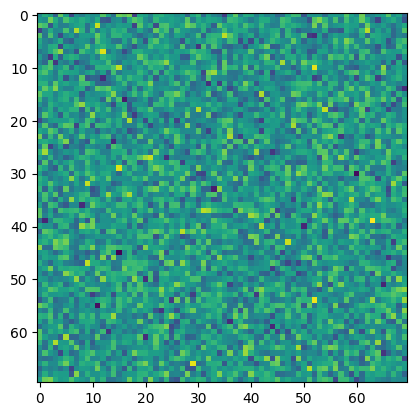

In [57]:
plt.imshow(model_learned_op.P2.cpu().detach())

In [48]:
# degrees reordered so 0° is visually centered
degrees = np.array(range(0,28,2))

acc_list_no_op = {}

for d1 in (degrees):
    for d2 in (degrees):
        ds = PolygonDataset(
            csv_file="mnist_dataset_split.csv",
            split="test",
            transform=transform,
            keep_degrees=(d1, d2),
        )
        loader = DataLoader(ds, batch_size=512, shuffle=False)
        
        acc_list_no_op[(d1//2, d2//2)] = evaluate_fixed_op_model(model_learned_op,  loader,d1, d2, device)


0.9571794016238461
0.9476142809476142
0.9448337226115003
0.9412746079412746
0.9443888332777222
0.9535090646201757
0.9555110666221778
0.9540651762873985
0.9498387276165053
0.9558447336225114
0.9555110666221778
0.9595150706261817
0.9584028472917362
0.958958958958959
0.9506172839506173
0.8698698698698699
0.7963519074630185
0.7731064397731064
0.7129351573796018
0.6720053386720053
0.608497386275164
0.5981537092648204
0.6264041819597375
0.6449783116449783
0.7062618173729285
0.7446335224113002
0.8202647091535981
0.9116894672450228
0.9513958402847291
0.8709820932043154
0.8263819374930486
0.8141474808141475
0.7428539650761873
0.676343009676343
0.5968190412634857
0.5701256812367923
0.6327438549660772
0.645311978645312
0.6952508063619175
0.7541986430875319
0.846290735179624
0.9152485819152486
0.9550661772883995
0.8802135468802136
0.8429540651762873
0.8145923701479257
0.7614280947614281
0.7132688243799354
0.6379713046379714
0.5832499165832499
0.6430875319764209
0.6645534423312202
0.707596485374263

In [49]:


# 1. Determine dimensions
max_d1 = max(k[0] for k in acc_list_no_op.keys())
max_d2 = max(k[1] for k in acc_list_no_op.keys())

# 2. Create empty matrix (initialized to zero or NaN)
grid = np.zeros((max_d1 + 1, max_d2 + 1))

# 3. Fill the matrix
for (d1, d2), acc in acc_list_no_op.items():
    grid[d1, d2] = acc


In [52]:
import numpy as np

# Save to a file named 'accuracy_grid.npy'
np.save('accuracy_grid_learned_P_full.npy', grid)

# To reload it later:
# grid = np.load('accuracy_grid.npy')


In [72]:
import numpy as np

# Load the binary file back into a variable
grid = np.load('accuracy_grid_learned_P_full.npy')

print(grid.shape)
print(grid)


(14, 14)
[[0.9571794  0.94761428 0.94483372 0.94127461 0.94438883 0.95350906
  0.95551107 0.95406518 0.94983873 0.95584473 0.95551107 0.95951507
  0.95840285 0.95895896]
 [0.95061728 0.86986987 0.79635191 0.77310644 0.71293516 0.67200534
  0.60849739 0.59815371 0.62640418 0.64497831 0.70626182 0.74463352
  0.82026471 0.91168947]
 [0.95139584 0.87098209 0.82638194 0.81414748 0.74285397 0.67634301
  0.59681904 0.57012568 0.63274385 0.64531198 0.69525081 0.75419864
  0.84629074 0.91524858]
 [0.95506618 0.88021355 0.84295407 0.81459237 0.76142809 0.71326882
  0.6379713  0.58324992 0.64308753 0.66455344 0.70759649 0.77677678
  0.87776666 0.92470248]
 [0.95506618 0.90345901 0.85274163 0.81648315 0.75408742 0.6787899
  0.66900234 0.57068179 0.64219775 0.66922478 0.76454232 0.84006228
  0.89367145 0.9238127 ]
 [0.95328662 0.89778668 0.83728173 0.81448115 0.7559782  0.68857747
  0.69580692 0.5712379  0.6538761  0.66555444 0.75008342 0.86575464
  0.89600712 0.92347903]
 [0.9561784  0.89522856 0.

In [79]:


# Assuming 'grid' is your (N, N) array from the previous step
N = grid.shape[0]
shift = N // 2

# Roll both axes to bring (0,0) to the center
shifted_grid = np.roll(grid, shift=(shift, shift), axis=(0, 1))

# Create labels that reflect the original d1, d2 values
# This ensures the tick marks say "0" in the middle
ticks = np.arange(N)
labels = (ticks - shift) *2


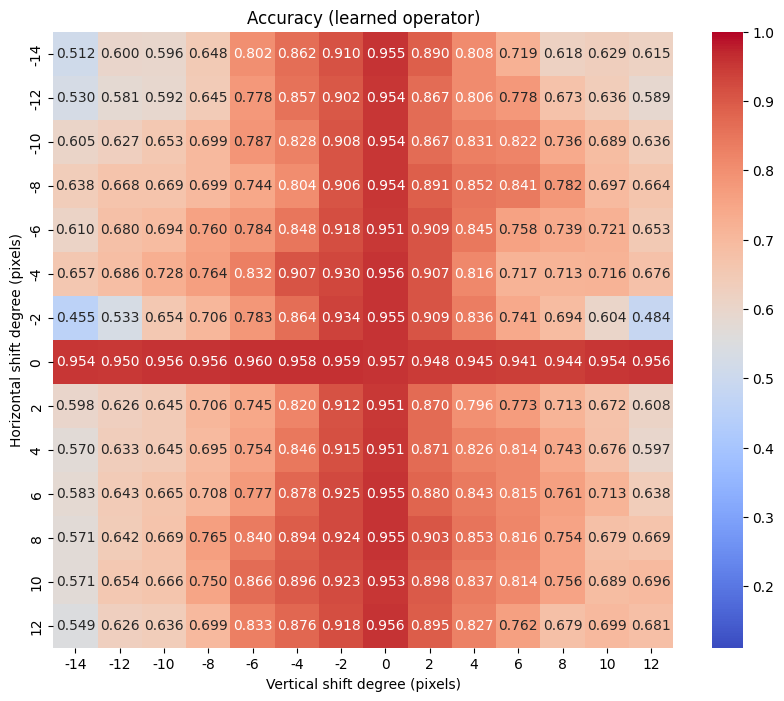

In [81]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    shifted_grid, 
    annot=True, 
    fmt=".3f", 
    cmap="coolwarm",
    vmin=1/9,
    vmax=1,
    xticklabels=labels, 
    yticklabels=labels
)

# Visual aid: draw lines to highlight the new center axes
#plt.axvline(shift + 0.5, color='white', linewidth=2, linestyle='--')
#plt.axhline(shift + 0.5, color='white', linewidth=2, linestyle='--')


plt.title("Accuracy (learned operator)")
plt.xlabel("Vertical shift degree (pixels)")
plt.ylabel("Horizontal shift degree (pixels)")
plt.show()

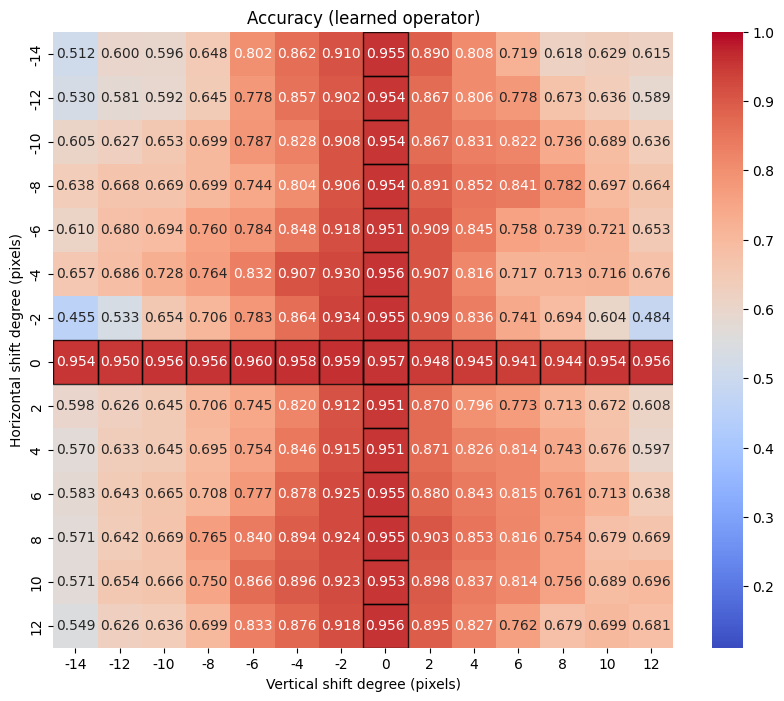

In [94]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.figure(figsize=(10, 8))

# 1. Plot the standard heatmap
ax = sns.heatmap(
    shifted_grid, 
    annot=True, 
    fmt=".3f", 
    cmap="coolwarm",
    vmin=1/9,
    vmax=1,
    xticklabels=labels, 
    yticklabels=labels
)

# 2. Identify the index where the label is 0
zero_pos = np.where(labels == 0)[0][0]

# 3. Add the //// pattern using patches
# We loop through the row and column corresponding to the zero-axis
N = shifted_grid.shape[0]

for i in range(N):
    # Hatch the row (d1 = 0)
    rect_h = patches.Rectangle((i, zero_pos), 1, 1, fill=False,  edgecolor='black', alpha=0.8)
    ax.add_patch(rect_h)
    
    # Hatch the column (d2 = 0)
    rect_v = patches.Rectangle((zero_pos, i), 1, 1, fill=False, edgecolor='black', alpha=0.8)
    ax.add_patch(rect_v)

plt.title("Accuracy (learned operator)")
plt.xlabel("Vertical shift degree (pixels)")
plt.ylabel("Horizontal shift degree (pixels)")
plt.show()
